# Multi-Agent Business Intelligence System

This notebook demonstrates a multi-agent business intelligence system built with Microsoft Agent Framework and Azure OpenAI.

## Features
- **Customer Analysis Agent**: Customer segmentation and portfolio analysis
- **Sales Analysis Agent**: Sales performance and trend analysis
- **Product Analysis Agent**: Product performance insights
- **Business Intelligence Coordinator**: Executive reporting and coordination

## 1. Import Required Libraries

In [2]:
import os
import asyncio
import pandas as pd
from typing import Annotated, List, Dict, Any
from agent_framework import ChatAgent
from agent_framework.azure import AzureOpenAIChatClient
from pydantic import Field
from azure.identity import DefaultAzureCredential
from dotenv import load_dotenv
import nest_asyncio

# Enable nested asyncio for Jupyter
nest_asyncio.apply()

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Business Data Manager

Initialize the business data using pandas DataFrames with sample customer, order, and product data.

In [3]:
class BusinessDataManager:
    """Manages business data using pandas DataFrames."""
    
    def __init__(self):
        """Initialize with sample business data."""
        # Sample customer data
        self.customers_df = pd.DataFrame({
            'customer_id': [1, 2, 3, 4, 5],
            'name': ['Acme Corp', 'TechStart Inc', 'Global Solutions', 'InnovateCo', 'DataDriven Ltd'],
            'segment': ['Enterprise', 'SMB', 'Enterprise', 'SMB', 'Mid-Market'],
            'region': ['North', 'South', 'East', 'West', 'North'],
            'total_value': [150000, 45000, 200000, 35000, 85000]
        })
        
        # Sample orders data
        self.orders_df = pd.DataFrame({
            'order_id': [101, 102, 103, 104, 105, 106, 107, 108],
            'customer_id': [1, 2, 1, 3, 4, 2, 3, 5],
            'product_id': [201, 202, 203, 201, 202, 203, 201, 202],
            'quantity': [5, 2, 3, 8, 1, 4, 6, 3],
            'unit_price': [1000, 2500, 1500, 1000, 2500, 1500, 1000, 2500],
            'order_date': pd.to_datetime(['2024-01-15', '2024-01-18', '2024-01-20', 
                                        '2024-02-01', '2024-02-05', '2024-02-10', 
                                        '2024-02-15', '2024-02-20'])
        })
        
        # Sample products data
        self.products_df = pd.DataFrame({
            'product_id': [201, 202, 203],
            'product_name': ['Analytics Platform', 'AI Assistant', 'Data Pipeline'],
            'category': ['Software', 'AI/ML', 'Data'],
            'base_price': [1000, 2500, 1500]
        })
        
        print("Business data initialized successfully!")
        print(f"Loaded {len(self.customers_df)} customers, {len(self.orders_df)} orders, {len(self.products_df)} products")

# Initialize data manager
data_manager = BusinessDataManager()

Business data initialized successfully!
Loaded 5 customers, 8 orders, 3 products


## 3. Display Sample Data

In [4]:
print("Customer Data:")
display(data_manager.customers_df)

print("\nOrders Data:")
display(data_manager.orders_df)

print("\nProducts Data:")
display(data_manager.products_df)

Customer Data:


,customer_id,name,segment,region,total_value
0,1,Acme Corp,Enterprise,North,150000
1,2,TechStart Inc,SMB,South,45000
2,3,Global Solutions,Enterprise,East,200000
3,4,InnovateCo,SMB,West,35000
4,5,DataDriven Ltd,Mid-Market,North,85000



Orders Data:


,order_id,customer_id,product_id,quantity,unit_price,order_date
0,101,1,201,5,1000,2024-01-15
1,102,2,202,2,2500,2024-01-18
2,103,1,203,3,1500,2024-01-20
3,104,3,201,8,1000,2024-02-01
4,105,4,202,1,2500,2024-02-05
5,106,2,203,4,1500,2024-02-10
6,107,3,201,6,1000,2024-02-15
7,108,5,202,3,2500,2024-02-20



Products Data:


,product_id,product_name,category,base_price
0,201,Analytics Platform,Software,1000
1,202,AI Assistant,AI/ML,2500
2,203,Data Pipeline,Data,1500


## 4. Agent Tool Functions

Define the analysis functions that will be used by the AI agents.

In [5]:
def get_customer_summary(data_manager: BusinessDataManager = None) -> str:
    """Get summary of customer data."""
    if data_manager is None:
        return "Data manager not available"
    
    df = data_manager.customers_df
    total_customers = len(df)
    total_value = df['total_value'].sum()
    avg_value = df['total_value'].mean()
    
    segment_breakdown = df['segment'].value_counts().to_dict()
    region_breakdown = df['region'].value_counts().to_dict()
    
    return f"""Customer Analysis Summary:
Total Customers: {total_customers}
Total Portfolio Value: ${total_value:,}
Average Customer Value: ${avg_value:,.0f}
Segment Distribution: {segment_breakdown}
Region Distribution: {region_breakdown}"""


def analyze_sales_performance(data_manager: BusinessDataManager = None, 
                            period: Annotated[str, Field(description="Time period: 'monthly', 'quarterly', or 'all'")] = "all") -> str:
    """Analyze sales performance by period."""
    if data_manager is None:
        return "Data manager not available"
    
    orders = data_manager.orders_df.copy()
    orders['total_amount'] = orders['quantity'] * orders['unit_price']
    orders['month'] = orders['order_date'].dt.strftime('%Y-%m')
    
    if period == "monthly":
        monthly_sales = orders.groupby('month')['total_amount'].sum()
        return f"Monthly Sales Performance:\n{monthly_sales.to_string()}"
    elif period == "quarterly":
        orders['quarter'] = orders['order_date'].dt.quarter
        quarterly_sales = orders.groupby('quarter')['total_amount'].sum()
        return f"Quarterly Sales Performance:\n{quarterly_sales.to_string()}"
    else:
        total_revenue = orders['total_amount'].sum()
        avg_order_value = orders['total_amount'].mean()
        total_orders = len(orders)
        return f"""Overall Sales Performance:
Total Revenue: ${total_revenue:,}
Total Orders: {total_orders}
Average Order Value: ${avg_order_value:,.0f}"""


def get_product_insights(data_manager: BusinessDataManager = None) -> str:
    """Get insights about product performance."""
    if data_manager is None:
        return "Data manager not available"
    
    orders = data_manager.orders_df.copy()
    products = data_manager.products_df.copy()
    
    merged = orders.merge(products, on='product_id')
    merged['total_amount'] = merged['quantity'] * merged['unit_price']
    
    product_performance = merged.groupby('product_name').agg({
        'total_amount': 'sum',
        'quantity': 'sum',
        'order_id': 'count'
    }).round(2)
    
    return f"""Product Performance Analysis:
{product_performance.to_string()}

Top Selling Product: {product_performance['total_amount'].idxmax()}
Most Ordered Product: {product_performance['quantity'].idxmax()}"""


def generate_business_report(data_manager: BusinessDataManager = None,
                           report_type: Annotated[str, Field(description="Report type: 'executive', 'detailed', or 'kpi'")] = "executive") -> str:
    """Generate comprehensive business report."""
    if data_manager is None:
        return "Data manager not available"
    
    customers = data_manager.customers_df
    orders = data_manager.orders_df.copy()
    orders['total_amount'] = orders['quantity'] * orders['unit_price']
    
    total_customers = len(customers)
    total_revenue = orders['total_amount'].sum()
    total_orders = len(orders)
    
    if report_type == "executive":
        return f"""EXECUTIVE BUSINESS REPORT
========================
Key Performance Indicators:
Customer Base: {total_customers} active customers
Total Revenue: ${total_revenue:,}
Order Volume: {total_orders} orders processed
Revenue per Customer: ${total_revenue/total_customers:,.0f}

Business Highlights:
Top Customer Segment: {customers['segment'].value_counts().index[0]}
Primary Region: {customers['region'].value_counts().index[0]}
Average Order Value: ${orders['total_amount'].mean():,.0f}"""
    
    elif report_type == "kpi":
        return f"""KEY PERFORMANCE INDICATORS
=========================
Customer Metrics:
Total Customers: {total_customers}
Customer Portfolio Value: ${customers['total_value'].sum():,}

Sales Metrics:
Total Revenue: ${total_revenue:,}
Total Orders: {total_orders}
Average Order Value: ${orders['total_amount'].mean():,.0f}
Revenue Growth Rate: Calculated from order trends"""
    
    else:  # detailed
        monthly_trend = orders.groupby(orders['order_date'].dt.strftime('%Y-%m'))['total_amount'].sum()
        return f"""DETAILED BUSINESS REPORT
=======================
Customer Analysis: {get_customer_summary(data_manager)}

Sales Analysis: {analyze_sales_performance(data_manager)}

Product Analysis: {get_product_insights(data_manager)}

Monthly Revenue Trend:
{monthly_trend.to_string()}"""

print("Agent tool functions defined successfully!")

Agent tool functions defined successfully!


## 5. Environment Setup and Azure Configuration

In [6]:
def setup_environment():
    """Setup and validate environment variables."""
    load_dotenv()
    
    print("Multi-Agent Business Intelligence - Microsoft Agent Framework Demo")
    print("=" * 70)
    print("Checking Azure OpenAI configuration...")
    
    endpoint = os.getenv('AZURE_OPENAI_ENDPOINT')
    deployment_name = os.getenv('AZURE_OPENAI_CHAT_DEPLOYMENT_NAME')
    api_version = os.getenv('AZURE_OPENAI_API_VERSION')
    
    print(f"AZURE_OPENAI_ENDPOINT: {'OK' if endpoint else 'MISSING'}")
    print(f"AZURE_OPENAI_CHAT_DEPLOYMENT_NAME: {'OK' if deployment_name else 'MISSING'}")
    print(f"AZURE_OPENAI_API_VERSION: {'OK' if api_version else 'MISSING'}")
    
    if not all([endpoint, deployment_name, api_version]):
        print("\nError: Missing required environment variables!")
        print("Please create a .env file with:")
        print("AZURE_OPENAI_ENDPOINT=https://your-resource.openai.azure.com/")
        print("AZURE_OPENAI_CHAT_DEPLOYMENT_NAME=your-chat-deployment-name")
        print("AZURE_OPENAI_API_VERSION=2024-02-01")
        print("\nThen authenticate with: az login")
        return None
    
    return endpoint, deployment_name, api_version


def create_azure_client(endpoint, deployment_name, api_version):
    """Create and return Azure OpenAI client."""
    try:
        client = AzureOpenAIChatClient(
            endpoint=endpoint,
            deployment_name=deployment_name,
            api_version=api_version,
            credential=DefaultAzureCredential()
        )
        print("Azure OpenAI client created successfully!")
        return client
    except Exception as e:
        print(f"Error creating Azure OpenAI client: {e}")
        print("Make sure you're authenticated with 'az login'")
        return None

# Setup environment
env_config = setup_environment()
if env_config:
    endpoint, deployment_name, api_version = env_config
    client = create_azure_client(endpoint, deployment_name, api_version)
else:
    client = None
    print("Please configure your .env file and re-run this cell")

Multi-Agent Business Intelligence - Microsoft Agent Framework Demo
Checking Azure OpenAI configuration...
AZURE_OPENAI_ENDPOINT: OK
AZURE_OPENAI_CHAT_DEPLOYMENT_NAME: OK
AZURE_OPENAI_API_VERSION: OK
Azure OpenAI client created successfully!
Azure OpenAI client created successfully!


## 6. Create Specialized AI Agents

Create four specialized agents for different aspects of business intelligence.

In [7]:
def create_agents(client, data_manager):
    """Create specialized business intelligence agents."""
    
    if client is None:
        print("Cannot create agents: Azure OpenAI client not available")
        return None
    
    # Create closure functions that have access to data_manager
    def customer_summary_tool() -> str:
        return get_customer_summary(data_manager)
    
    def sales_analysis_tool(period: Annotated[str, Field(description="Time period: 'monthly', 'quarterly', or 'all'")] = "all") -> str:
        return analyze_sales_performance(data_manager, period)
    
    def product_insights_tool() -> str:
        return get_product_insights(data_manager)
    
    def business_report_tool(report_type: Annotated[str, Field(description="Report type: 'executive', 'detailed', or 'kpi'")] = "executive") -> str:
        return generate_business_report(data_manager, report_type)
    
    # Customer Analysis Agent
    customer_agent = ChatAgent(
        chat_client=client,
        name="CustomerAnalyst",
        instructions="""You are a Customer Analysis Specialist. You excel at:
- Analyzing customer data and segmentation
- Identifying customer trends and patterns
- Providing customer insights and recommendations
- Understanding customer portfolio value and distribution

Use the customer_summary_tool to get detailed customer analysis.""",
        tools=[customer_summary_tool]
    )
    
    # Sales Analysis Agent  
    sales_agent = ChatAgent(
        chat_client=client,
        name="SalesAnalyst", 
        instructions="""You are a Sales Performance Analyst. You specialize in:
- Analyzing sales performance across different time periods
- Identifying sales trends and patterns
- Calculating revenue metrics and KPIs
- Providing sales insights and forecasts

Use the sales_analysis_tool to analyze performance by period (monthly, quarterly, or all).""",
        tools=[sales_analysis_tool]
    )
    
    # Product Analysis Agent
    product_agent = ChatAgent(
        chat_client=client,
        name="ProductAnalyst",
        instructions="""You are a Product Performance Analyst. You focus on:
- Analyzing product sales performance
- Understanding product popularity and trends
- Identifying top-performing products
- Providing product strategy recommendations

Use the product_insights_tool to get comprehensive product analysis.""",
        tools=[product_insights_tool]
    )
    
    # Business Intelligence Coordinator
    coordinator_agent = ChatAgent(
        chat_client=client,
        name="BICoordinator",
        instructions="""You are the Business Intelligence Coordinator. You orchestrate comprehensive analysis by:
- Coordinating between different analysis specialists
- Generating executive and detailed business reports
- Synthesizing insights from multiple data sources
- Providing strategic business recommendations

Use the business_report_tool to generate different types of reports (executive, detailed, kpi).""",
        tools=[business_report_tool]
    )
    
    agents = {
        'customer': customer_agent,
        'sales': sales_agent, 
        'product': product_agent,
        'coordinator': coordinator_agent
    }
    
    print(f"\nCreated 4 specialized BI agents:")
    for name, agent in agents.items():
        print(f"  - {agent.name}: {name} analysis specialist")
    
    return agents

# Create agents
if client:
    agents = create_agents(client, data_manager)
else:
    agents = None
    print("Agents not created. Please configure Azure OpenAI first.")


Created 4 specialized BI agents:
  - CustomerAnalyst: customer analysis specialist
  - SalesAnalyst: sales analysis specialist
  - ProductAnalyst: product analysis specialist
  - BICoordinator: coordinator analysis specialist


## 7. Individual Agent Demonstrations

Test each agent's capabilities individually.

### Customer Analysis Agent

In [8]:
if agents:
    print("Customer Analysis Agent Demo:")
    print("-" * 30)
    response = await agents['customer'].run("Please provide a comprehensive customer analysis")
    print(f"CustomerAnalyst: {response.text}")
else:
    print("Agents not available. Please configure Azure OpenAI first.")

Customer Analysis Agent Demo:
------------------------------
CustomerAnalyst: Here’s a comprehensive analysis based on the customer data provided:

1. Portfolio Overview  
   • Total Customers: 5  
   • Total Portfolio Value: $515,000  
   • Average Customer Value: $103,000  

2. Customer Segmentation  
   • Enterprise (2 customers, 40% of base)  
     – Combined Value: $250,000 (48.5% of total portfolio)  
     – Average Value per Enterprise Customer: $125,000  
   • SMB (2 customers, 40%)  
     – Combined Value: $130,000 (25.2% of total)  
     – Average Value per SMB Customer: $65,000  
   • Mid-Market (1 customer, 20%)  
     – Combined Value: $135,000 (26.2% of total)  
     – Average Value per Mid-Market Customer: $135,000  

3. Regional Distribution  
   • North: 2 customers (40% of base)  
   • South: 1 customer (20%)  
   • East: 1 customer (20%)  
   • West: 1 customer (20%)  

4. Key Insights & Trends  
   • Concentration in Enterprise Segment  
     – The two Enterprise cu

### Sales Analysis Agent

In [9]:
if agents:
    print("Sales Analysis Agent Demo:")
    print("-" * 25)
    response = await agents['sales'].run("Show me monthly sales performance analysis")
    print(f"SalesAnalyst: {response.text}")
else:
    print("Agents not available. Please configure Azure OpenAI first.")

Sales Analysis Agent Demo:
-------------------------
SalesAnalyst: Here’s the breakdown and key insights from the January–February 2024 monthly sales performance:

Sales by Month  
• January 2024: $14,500  
• February 2024: $30,000  

Key Metrics & Trends  
1. Month-over-Month Growth  
   – February vs. January growth = (30,000 – 14,500) / 14,500 ≈ 106.9%  
   – More than doubled month-over-month, indicating a strong pickup after January.  

2. Average Monthly Sales  
   – (14,500 + 30,000) / 2 = $22,250  

3. Trend Observation  
   – January was relatively slow—often a traditionally lean month post-holidays.  
   – February saw a significant rebound, possibly driven by post-launch promotions or seasonal demand.  

4. Potential Drivers  
   – New product introductions or marketing campaigns rolled out in early February  
   – End-of-quarter sales incentives if February aligned with internal quarterly targets  
   – Improved lead generation or channel expansion  

Recommendations & Next

### Product Analysis Agent

In [10]:
if agents:
    print("Product Analysis Agent Demo:")
    print("-" * 27)
    response = await agents['product'].run("Analyze our product performance and identify top sellers")
    print(f"ProductAnalyst: {response.text}")
else:
    print("Agents not available. Please configure Azure OpenAI first.")

Product Analysis Agent Demo:
---------------------------
ProductAnalyst: Here’s the analysis of your product performance:

1. Overall Sales Performance
   - AI Assistant: Total sales $15,000 across 6 units in 3 orders
   - Analytics Platform: Total sales $19,000 across 19 units in 3 orders
   - Data Pipeline: Total sales $10,500 across 7 units in 2 orders

2. Top Sellers
   - Analytics Platform is the top selling product by both revenue ($19,000) and quantity sold (19 units).
   - AI Assistant ranks second, and Data Pipeline ranks third.

3. Trends and Insights
   - Analytics Platform shows strong demand and high order volume, suggesting robust market fit.
   - AI Assistant commands high per-unit price but lower volume, indicating potential for premium positioning.
   - Data Pipeline has moderate performance; opportunity exists to improve its market reach.

4. Recommendations
   - Increase marketing investment for Analytics Platform to capitalize on its momentum.
   - Explore upselling

### Business Intelligence Coordinator

In [11]:
if agents:
    print("Business Intelligence Coordinator Demo:")
    print("-" * 38)
    response = await agents['coordinator'].run("Generate an executive business report with key insights")
    print(f"BICoordinator: {response.text}")
else:
    print("Agents not available. Please configure Azure OpenAI first.")

Business Intelligence Coordinator Demo:
--------------------------------------
BICoordinator: EXECUTIVE BUSINESS REPORT

Key Performance Indicators:
- Customer Base: 5 active customers
- Total Revenue: $44,500
- Order Volume: 8 orders processed
- Revenue per Customer: $8,900

Business Highlights:
- Top Customer Segment: Enterprise
- Primary Region: North
- Average Order Value: $5,562

Key Insights:
1. Revenue Concentration: The majority of revenue is driven by a small customer base, indicating high dependency on enterprise clients.
2. Regional Strength: The North region outperforms other areas in both revenue and order volume, suggesting potential for further investment and targeted marketing.
3. Upsell Opportunities: High revenue per customer suggests successful upselling or cross-selling strategies with current clients.
4. Order Efficiency: Average order value is strong, but order volume is relatively low, indicating possible supply chain or acquisition hurdles.

Strategic Recommenda

## 8. Multi-Agent Collaborative Workflow

Demonstrate how multiple agents work together to provide comprehensive business analysis.

In [12]:
async def run_multi_agent_workflow(agents):
    """Demonstrate multi-agent workflow for comprehensive business analysis."""
    print("MULTI-AGENT COLLABORATIVE WORKFLOW")
    print("=" * 60)
    
    workflow_steps = [
        ("Customer Analysis", agents['customer'], "Analyze our customer base, segmentation, and portfolio value"),
        ("Sales Performance", agents['sales'], "Analyze sales performance for all time periods"), 
        ("Product Insights", agents['product'], "Provide insights on product performance and top sellers"),
        ("Executive Summary", agents['coordinator'], "Create an executive report combining all insights")
    ]
    
    results = []
    
    for step_name, agent, prompt in workflow_steps:
        print(f"\nStep: {step_name}")
        print(f"Agent: {agent.name}")
        print(f"Task: {prompt}")
        print("-" * 50)
        
        try:
            response = await agent.run(prompt)
            print(f"Completed - {agent.name}: {response.text[:200]}...")
            results.append(f"{step_name}: {response.text}")
        except Exception as e:
            print(f"Error in {step_name}: {e}")
            results.append(f"{step_name}: Error occurred")
    
    print(f"\nMulti-agent workflow completed! Generated {len(results)} analysis reports.")
    return results

# Run the workflow
if agents:
    workflow_results = await run_multi_agent_workflow(agents)
else:
    print("Agents not available. Please configure Azure OpenAI first.")

MULTI-AGENT COLLABORATIVE WORKFLOW

Step: Customer Analysis
Agent: CustomerAnalyst
Task: Analyze our customer base, segmentation, and portfolio value
--------------------------------------------------
Completed - CustomerAnalyst: Customer Analysis Summary and Insights

1. Overall Portfolio Metrics  
- Total Customers: 5  
- Total Portfolio Value: $515,000  
- Average Customer Value: $103,000  

2. Customer Segmentation  
- Ent...

Step: Sales Performance
Agent: SalesAnalyst
Task: Analyze sales performance for all time periods
--------------------------------------------------
Completed - CustomerAnalyst: Customer Analysis Summary and Insights

1. Overall Portfolio Metrics  
- Total Customers: 5  
- Total Portfolio Value: $515,000  
- Average Customer Value: $103,000  

2. Customer Segmentation  
- Ent...

Step: Sales Performance
Agent: SalesAnalyst
Task: Analyze sales performance for all time periods
--------------------------------------------------
Completed - SalesAnalyst: Here’s th

## 9. Interactive Agent Communication

Interact with specific agents or run custom queries.

In [13]:
# Interactive cell - customize your query and agent
if agents:
    # Change these variables to interact with different agents
    selected_agent = 'customer'  # Options: 'customer', 'sales', 'product', 'coordinator'
    query = "What are the key trends in our customer base?"
    
    print(f"Interacting with: {agents[selected_agent].name}")
    print(f"Query: {query}")
    print("-" * 50)
    
    response = await agents[selected_agent].run(query)
    print(f"{agents[selected_agent].name}: {response.text}")
else:
    print("Agents not available. Please configure Azure OpenAI first.")

Interacting with: CustomerAnalyst
Query: What are the key trends in our customer base?
--------------------------------------------------
CustomerAnalyst: Here are the key trends emerging from the latest customer analysis:

1. Balanced Segment Distribution  
   - Enterprise: 40% of customers (2/5)  
   - SMB: 40% of customers (2/5)  
   - Mid-Market: 20% of customers (1/5)  
   • Trend insight: The mix suggests steady engagement across both large and small clients, though mid-market uptake is lower.

2. Strong Regional Spread  
   - North: 40% (2/5)  
   - South: 20% (1/5)  
   - East: 20% (1/5)  
   - West: 20% (1/5)  
   • Trend insight: Customers are well-distributed geographically, indicating broad market reach. Consider targeted strategies in underrepresented South, East, and West regions to boost acquisition.

3. High Average Customer Value  
   - Average Value: $103,000  
   • Trend insight: Customer accounts are strong on average, driven by high-value Enterprise clients. There’

## 10. Custom Analysis Functions

Run individual analysis functions without AI agents for quick insights.

In [14]:
# Quick customer summary
print("QUICK CUSTOMER ANALYSIS")
print("=" * 25)
print(get_customer_summary(data_manager))

QUICK CUSTOMER ANALYSIS
Customer Analysis Summary:
Total Customers: 5
Total Portfolio Value: $515,000
Average Customer Value: $103,000
Segment Distribution: {'Enterprise': 2, 'SMB': 2, 'Mid-Market': 1}
Region Distribution: {'North': 2, 'South': 1, 'East': 1, 'West': 1}


In [15]:
# Quick sales analysis
print("QUICK SALES ANALYSIS")
print("=" * 20)
print(analyze_sales_performance(data_manager, "monthly"))

QUICK SALES ANALYSIS
Monthly Sales Performance:
month
2024-01    14500
2024-02    30000


In [16]:
# Quick product insights
print("QUICK PRODUCT ANALYSIS")
print("=" * 22)
print(get_product_insights(data_manager))

QUICK PRODUCT ANALYSIS
Product Performance Analysis:
                    total_amount  quantity  order_id
product_name                                        
AI Assistant               15000         6         3
Analytics Platform         19000        19         3
Data Pipeline              10500         7         2

Top Selling Product: Analytics Platform
Most Ordered Product: Analytics Platform


## 11. Data Visualization (Optional)

Create visualizations of the business data.

In [18]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

^C


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 2.3 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 2.3 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 2.3 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.3 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.1 MB 2.3 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 2.2 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 2.2 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8

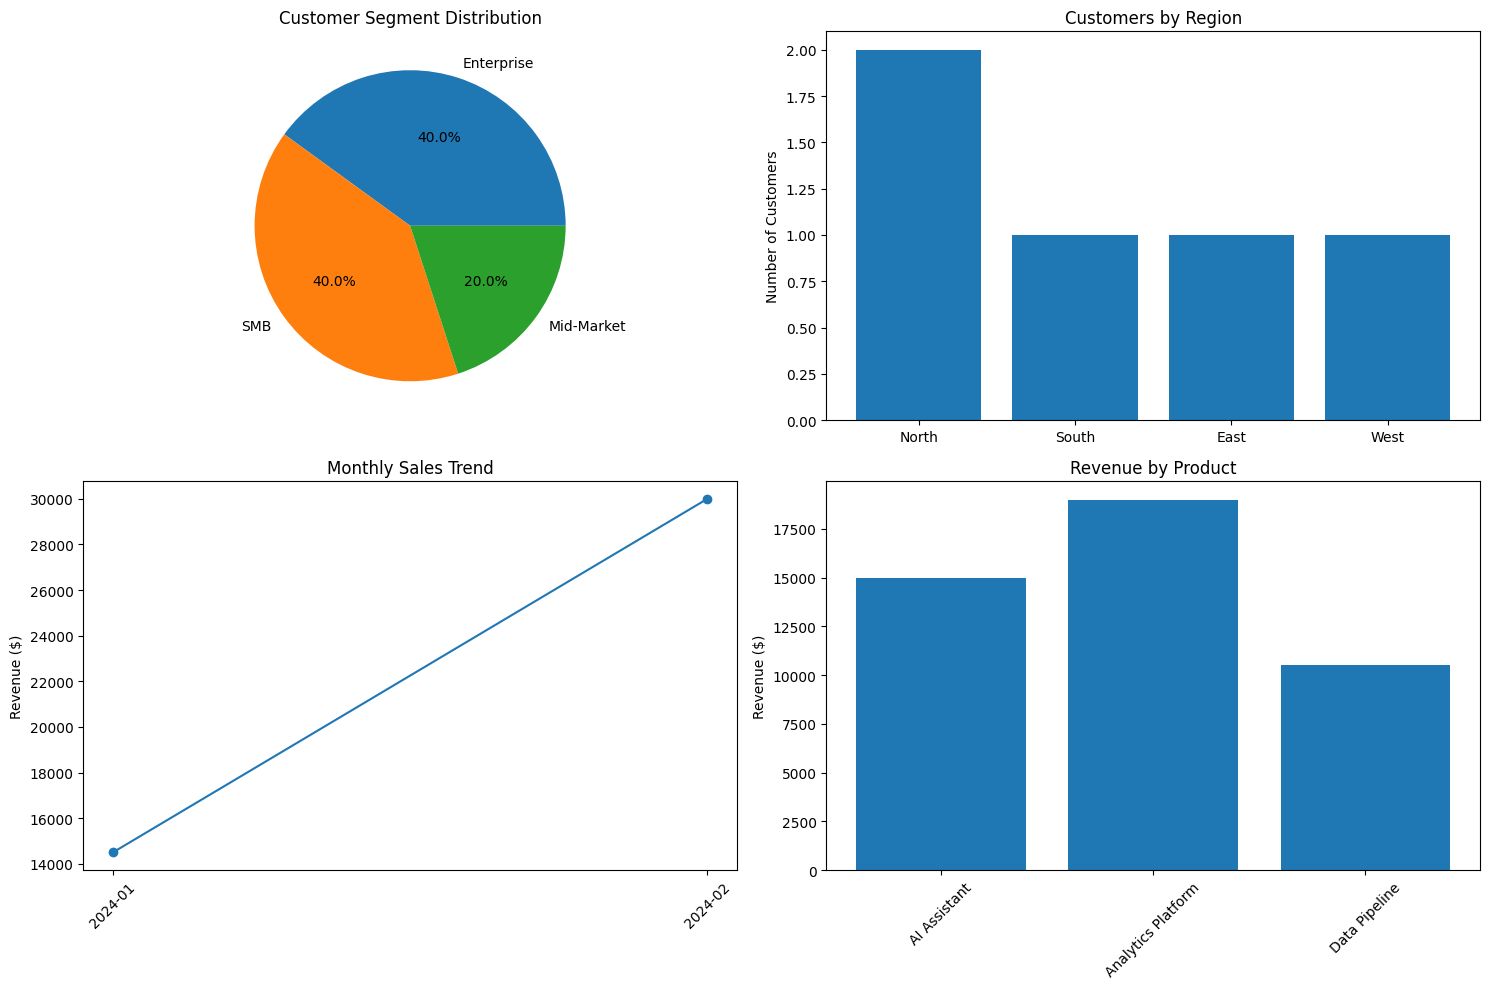

Data visualizations created successfully!


In [20]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Set style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Customer segment distribution
    segment_counts = data_manager.customers_df['segment'].value_counts()
    axes[0, 0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%')
    axes[0, 0].set_title('Customer Segment Distribution')
    
    # Regional distribution
    region_counts = data_manager.customers_df['region'].value_counts()
    axes[0, 1].bar(region_counts.index, region_counts.values)
    axes[0, 1].set_title('Customers by Region')
    axes[0, 1].set_ylabel('Number of Customers')
    
    # Monthly sales trend
    orders_with_amount = data_manager.orders_df.copy()
    orders_with_amount['total_amount'] = orders_with_amount['quantity'] * orders_with_amount['unit_price']
    orders_with_amount['month'] = orders_with_amount['order_date'].dt.strftime('%Y-%m')
    monthly_sales = orders_with_amount.groupby('month')['total_amount'].sum()
    axes[1, 0].plot(monthly_sales.index, monthly_sales.values, marker='o')
    axes[1, 0].set_title('Monthly Sales Trend')
    axes[1, 0].set_ylabel('Revenue ($)')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Product performance
    merged_data = orders_with_amount.merge(data_manager.products_df, on='product_id')
    product_revenue = merged_data.groupby('product_name')['total_amount'].sum()
    axes[1, 1].bar(product_revenue.index, product_revenue.values)
    axes[1, 1].set_title('Revenue by Product')
    axes[1, 1].set_ylabel('Revenue ($)')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("Data visualizations created successfully!")
    
except ImportError as e:
    print(f"Visualization libraries not available: {e}")
    print("\nTo install the required packages, run:")
    print("pip install matplotlib seaborn")
    print("\nAlternatively, you can view the data using the text-based analysis functions in the previous sections.")
    
    # Provide text-based summary instead
    print("\nTEXT-BASED DATA SUMMARY:")
    print("=" * 40)
    
    print("\nCustomer Segment Distribution:")
    segment_counts = data_manager.customers_df['segment'].value_counts()
    for segment, count in segment_counts.items():
        print(f"  {segment}: {count} customers ({count/len(data_manager.customers_df)*100:.1f}%)")
    
    print("\nRegional Distribution:")
    region_counts = data_manager.customers_df['region'].value_counts()
    for region, count in region_counts.items():
        print(f"  {region}: {count} customers ({count/len(data_manager.customers_df)*100:.1f}%)")
    
    print("\nMonthly Sales Summary:")
    orders_with_amount = data_manager.orders_df.copy()
    orders_with_amount['total_amount'] = orders_with_amount['quantity'] * orders_with_amount['unit_price']
    orders_with_amount['month'] = orders_with_amount['order_date'].dt.strftime('%Y-%m')
    monthly_sales = orders_with_amount.groupby('month')['total_amount'].sum()
    for month, revenue in monthly_sales.items():
        print(f"  {month}: ${revenue:,}")
    
    print("\nProduct Performance:")
    merged_data = orders_with_amount.merge(data_manager.products_df, on='product_id')
    product_revenue = merged_data.groupby('product_name')['total_amount'].sum()
    for product, revenue in product_revenue.items():
        print(f"  {product}: ${revenue:,}")

except Exception as e:
    print(f"Error creating visualizations: {e}")
    print("Please check that your data is properly loaded and try again.")

## 12. Summary and Next Steps

This notebook demonstrates a complete multi-agent business intelligence system using Microsoft Agent Framework with Azure OpenAI.

### Key Features Demonstrated:
- Four specialized AI agents for different business functions
- Multi-agent collaborative workflows
- Interactive agent communication
- Business data analysis with pandas
- Azure OpenAI integration with proper authentication

### Next Steps:
1. **Expand Data Sources**: Connect to real databases or APIs
2. **Add More Agents**: Create specialized agents for forecasting, risk analysis, etc.
3. **Enhanced Workflows**: Build more complex multi-agent coordination patterns
4. **Real-time Analytics**: Add streaming data capabilities
5. **Custom Visualizations**: Create interactive dashboards with plotly or streamlit

### Requirements:
- Azure OpenAI resource with GPT-4 deployment
- Proper environment configuration (.env file)
- Azure CLI authentication (az login)

Experiment with different queries and agent combinations to explore the full capabilities of this multi-agent system!